Labels : [0 0 0 1 1 1 1 2]
Centroids : [[ 2.33333333  2.33333333]
 [10.25       11.25      ]
 [ 4.         10.        ]]
Cluster with Label
    X   Y  Cluster
0   2   2        0
1   2   3        0
2   3   2        0
3  10  10        1
4  10  11        1
5  10  12        1
6  11  12        1
7   4  10        2


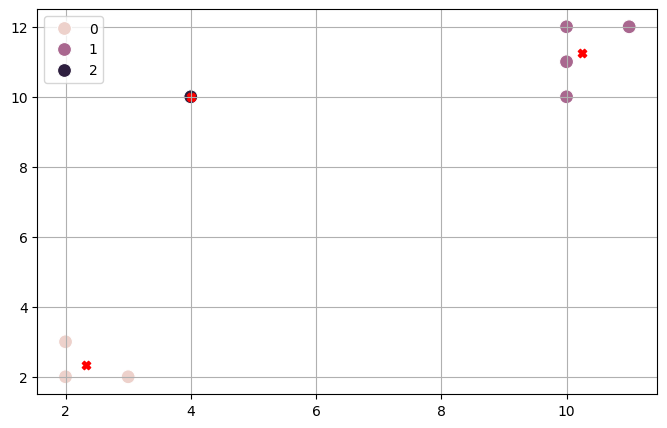

In [ ]:
import numpy as np
points = np.array([[2,2],[2,3],[3,2],[10,10],[10,11],[10,12],[11,12],[4,10]])

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(points)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print('Labels :',labels)
print('Centroids :',centroids)

import pandas as pd
df = pd.DataFrame(points, columns=['X', 'Y'])
df['Cluster'] = labels  # Assign cluster labels
print('Cluster with Label')
print(df)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(x=points[:,0],y=points[:,1],hue = labels, s=100)
plt.scatter(x = centroids[:,0],y = centroids[:,1],marker='X',color='red')
plt.grid()
plt.show()

   X  Y  Cluster
0  2  3        0
1  3  2        0
2  2  2        0
3  3  3        0
    X   Y  Cluster
4  10  10        1
5  10  11        1
6  11  11        1
7  12  12        1


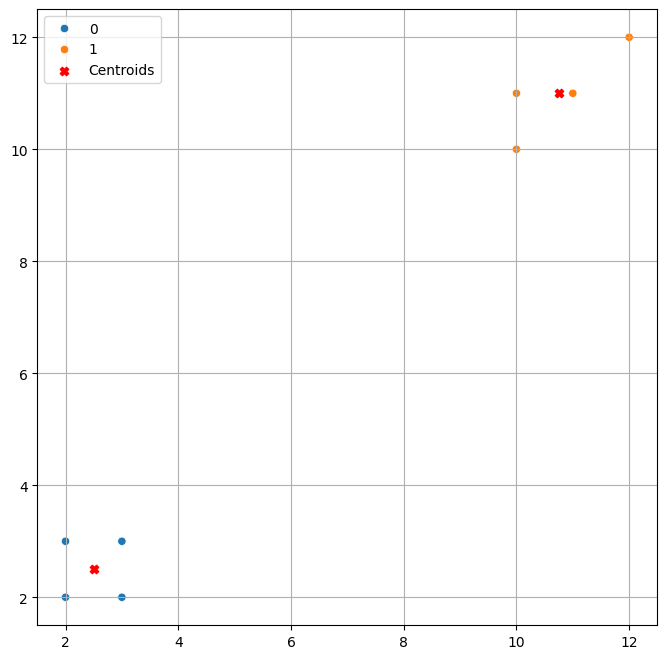

In [1]:
import numpy as np
points = np.array([[2,3],[3,2],[2,2],[3,3],[10,10],[10,11],[11,11],[12,12]])


#K-Means Model
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)
kmeans.fit(points)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_


import pandas as pd
df_points = pd.DataFrame(points,columns=['X','Y'])
df_points['Cluster'] = labels

for cluster in range(2):
  cluster_points = df_points[df_points['Cluster']==cluster]
  print(cluster_points)


#visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,8))
sns.scatterplot(x = points[:,0],y=points[:,1],hue = labels)
plt.scatter(x = centroids[:,0],y=centroids[:,1],marker='X',color='red',label='Centroids')
plt.grid()
plt.legend()
plt.show()

    X  Y  cluster
0   1  4        0
1   5  1        0
2   5  2        0
3   5  4        0
4  10  4        0
5  25  4        1
6  25  6        1
7  25  7        1
8  25  8        1
9  29  7        1


<ipython-input-70-61e60d59c9e5>:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


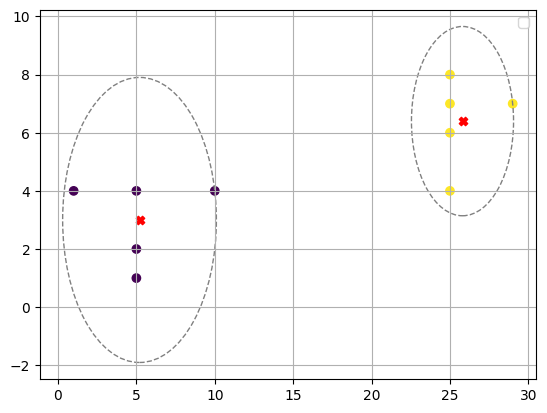

In [ ]:
import numpy as np
points = np.array([[2,2],[3,3],[6,6],[6,7]])

from sklearn.cluster import KMeans
km = KMeans(n_clusters=2)
km.fit(points)
labels = km.labels_
centroids = km.cluster_centers_

import pandas as pd
df = pd.DataFrame(points,columns=['X','Y'])
df['cluster'] = labels

print(df)

radii = []
for i in range(len(centroids)):
    cluster_points = points[labels == i]
    max_distance = np.max(np.linalg.norm(cluster_points - centroids[i], axis=1))
    radii.append(max_distance)

import matplotlib.pyplot as plt
plt.scatter(x = points[:,0],y=points[:,1],c=labels)
plt.scatter(x = centroids[:,0], y = centroids[:,1], marker='X',color = 'red')

# Draw circles around clusters
for i, centroid in enumerate(centroids):
    circle = plt.Circle(centroid, radii[i], color='gray', fill=False, linestyle='dashed')
    plt.gca().add_patch(circle)


plt.grid()
plt.legend()
plt.show()

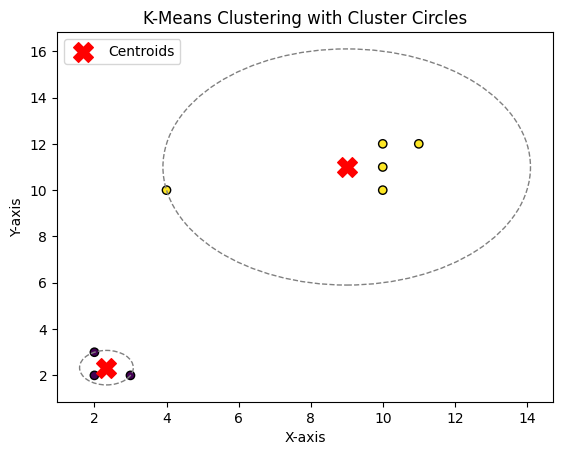

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample dataset
points = np.array([[2,2],[2,3],[3,2],[10,10],[10,11],[10,12],[11,12],[4,10]])

# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(points)
centroids = kmeans.cluster_centers_

# Compute radius (max distance from centroid in each cluster)
radii = []
for i in range(len(centroids)):
    cluster_points = points[labels == i]
    max_distance = np.max(np.linalg.norm(cluster_points - centroids[i], axis=1))
    radii.append(max_distance)

# Plot clusters
plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='viridis', marker='o', edgecolors='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label="Centroids")

# Draw circles around clusters
for i, centroid in enumerate(centroids):
    circle = plt.Circle(centroid, radii[i], color='gray', fill=False, linestyle='dashed')
    plt.gca().add_patch(circle)

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.title("K-Means Clustering with Cluster Circles")
plt.show()
